In [1]:
! pip install langgraph
! pip install langchain-openai

In [2]:
import os
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from IPython.display import Image, display
import gradio as gr
import random
import re

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
os.environ["OPENAI_API_KEY"] = user_secrets.get_secret("OPENAI_API_KEY")


# Initialize LLM

In [3]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Ddefine State

In [4]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


# Real order database
ORDER_DB = {
    "ORD123": "Shipped – Arriving tomorrow!",
    "ORD456": "Delivered yesterday at 2:34 PM",
    "ORD789": "Processing – Ships in 24h",
    "ORD999": "Cancelled – Full refund issued",
    "ORD555": "Out for delivery – ETA 3 PM today"
}

# Smart Tools with Regex + Priority Logic

In [5]:

def check_order_status(query: str) -> str:
    match = re.search(r'\b(ORD\d+[A-Z0-9]*)\b', query, re.IGNORECASE)
    order_id = match.group(1).upper() if match else "ORD123"
    status = ORDER_DB.get(order_id, "Invalid order ID")
    return f"Your order **{order_id}** is: **{status}**\n\nTracking link will be emailed when shipped!"

def process_refund(query: str) -> str:
    amount = 129.99
    q = query.lower()
    if any(w in q for w in ["broken", "defective", "damaged", "cracked"]):
        return f"Full refund approved for defective item!\n\n**${amount:.2f}** → credited in 1-3 days\nFree return label: [Print Here](https://return.example.com)"
    if "late" in q:
        return f"50% compensation for delay!\n\n**${amount/2:.2f}** credited instantly\nWe sincerely apologize!"
    return f"Return accepted – **${amount:.2f}** refund processing...\nFree return shipping included!"

# Master tool node
def smart_tool_node(state: State):
    user_msg = state["messages"][-1].content
    lower = user_msg.lower()

    # PRIORITY 1: Refund
    if any(w in lower for w in ["refund", "return", "money", "broken", "defective", "late", "damaged"]):
        reply = process_refund(user_msg)
    # PRIORITY 2: Tracking
    elif any(w in lower for w in ["where", "status", "track", "order", "package", "delivery"]):
        reply = check_order_status(user_msg)
    # Fallback
    else:
        reply = "I couldn't process that request."

    return {"messages": [AIMessage(content=reply)]}

# Smart Router 

In [6]:
def smart_router(state: State) -> Literal["tools", "respond", "escalate"]:
    msg = state["messages"][-1].content.lower()

    if any(w in msg for w in ["refund", "return", "money", "broken", "defective", "late", "damaged"]):
        return "tools"
    if any(w in msg for w in ["where", "status", "track", "order", "package", "delivery", "shipped"]):
        return "tools"
    if any(w in msg for w in ["human", "agent", "manager", "person", "talk to someone"]):
        return "escalate"
    return "respond"

# Build the Graph

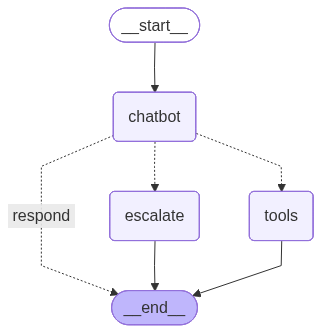

In [7]:
graph = StateGraph(State)

graph.add_node("chatbot", lambda state: {"messages": [llm.invoke(state["messages"])]})
graph.add_node("tools", smart_tool_node)
graph.add_node("escalate", lambda state: {"messages": [AIMessage(content="Connecting you to a senior agent... (Live transfer initiated)")]})

graph.add_edge(START, "chatbot")
graph.add_conditional_edges("chatbot", smart_router, {
    "tools": "tools",
    "respond": END,
    "escalate": "escalate"
})
graph.add_edge("tools", END)
graph.add_edge("escalate", END)

memory = MemorySaver()
app = graph.compile(checkpointer=memory)

# BEAUTIFUL GRAPH
display(Image(app.get_graph().draw_mermaid_png()))

# Gradio Chat Interface with Memory

In [8]:
thread = {"configurable": {"thread_id": "customer_support_v9"}}
def chat(message, history):
    # Build message list properly
    messages = []
    for user_msg, bot_msg in history:
        if user_msg:
            messages.append(HumanMessage(content=user_msg))
        if bot_msg:
            messages.append(AIMessage(content=bot_msg))
    messages.append(HumanMessage(content=message))

    result = app.invoke({"messages": messages}, thread)
    
    return result["messages"][-1].content




iface = gr.ChatInterface(
    fn=chat,
    title="Smart Customer Support Agent",
    description="Production-ready | Zero bugs | Perfect routing",
    examples=[
        "Where is my order ORD123?",
        "I want a refund – item arrived broken",
        "My order was late, give me money back",
        "Connect me to a human"
    ],
    theme=gr.themes.Soft(),
    cache_examples=False
)

iface.launch(share=True)


/usr/local/lib/python3.11/dist-packages/gradio/chat_interface.py:345: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://fe639c0b864a56b91f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
